In [1]:
import torch
import lightning
import cocodeel.dataset
import cocodeel.model
import cocodeel.posthoc_model

In [2]:
# Set default dtype, device and seed.
torch.set_default_dtype(torch.float)
torch.set_default_device("cpu")
torch.manual_seed(0)

## 1. Neural Network with Covariates

In [3]:
N = 10000
# Create data.
X = torch.randn(N, 2)
X = torch.cat((torch.ones(N, 1), X), 1)  # Add vector of ones at first position.
# U ~ X * delta + N(0,1)
U = torch.matmul(X[:,1:], torch.ones(2, 32)) + torch.randn(N, 32)
# y ~ X * beta + U * gamma + N(0,1)
y = (torch.matmul(X, torch.tensor([1., 1., 1.])) + 
     torch.matmul(U, torch.ones(32)) + 
                  torch.randn(N))
dataset = cocodeel.dataset.CovarDataset(U, X, y)
train_loader = torch.utils.data.DataLoader(dataset, batch_size=int(N/20), shuffle=True)

In [4]:
# Create model.
params = {
    "backbone": torch.nn.Linear,
    "output_func": torch.nn.Identity,
    "loss_func": torch.nn.MSELoss,
    "num_features": 32,
    "num_covars": 3,
    "backbone_params": {"in_features": 32, "out_features": 32},
    "optimizer_params": {"lr": 0.1, "weight_decay": 0.}
}
net = cocodeel.model.CovarNeuralNetwork(**params)

In [5]:
# Train model.
trainer = lightning.Trainer(max_epochs=10)
trainer.fit(net, train_loader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
C:\Users\Manuel Pfeuffer\anaconda3\envs\cocodeel\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default

  | Name             | Type     | Params | Mode 
------------------------------------------------------
0 | backbone         | Linear   | 1.1 K  | train
1 | output_func      | Identity | 0      | train
2 | loss_func        | MSELoss  | 0      | train
3 | deep_predictor   | Linear   | 32     | train
4 | struct_predictor | Linear   | 3  

Epoch 9: 100%|██████████| 20/20 [00:00<00:00, 78.23it/s, v_num=57]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 20/20 [00:00<00:00, 76.11it/s, v_num=57]


## 2. Post-hoc Orthogoanlized Neural Network

In [6]:
# Train PHO model.
pho = cocodeel.posthoc_model.PostHocOrthogonalizedModel(net, train_loader)

## 3. Re-estimating last layer using least squares (LS)

In [7]:
# Train IWLS model.
phls = cocodeel.posthoc_model.PostHocLSModel(net, train_loader)
phols = cocodeel.posthoc_model.PostHocLSModel(net, train_loader, orthogonalize=True)

## Comparison of Models

In [8]:
# Compare coefficients of the three models.
print("Original model:")
print(net.struct_predictor.weight)
print("Post-hoc orthogonalized model:")
print(pho.model.struct_predictor.weight)
print("Post-hoc LS model:")
print(phls.model.struct_predictor.weight)
print("Post-hoc orthogonalized LS model:")
print(phols.model.struct_predictor.weight)

Original model:
Parameter containing:
tensor([[-0.1181,  1.0155,  1.0188]], requires_grad=True)
Post-hoc orthogonalized model:
Parameter containing:
tensor([[ 0.9092, 33.0491, 33.0702]], requires_grad=True)
Post-hoc LS model:
Parameter containing:
tensor([[-0.2981,  0.9173,  0.9308]])
Post-hoc orthogonalized LS model:
Parameter containing:
tensor([[ 0.8843, 32.9759, 33.0070]])


In [9]:
# Comparison of performance on test data.
N = 10000
U = torch.randn(N, 32)
X = torch.matmul(U, torch.ones(32, 2)) + torch.randn(N, 2)
X = torch.cat((torch.ones(N, 1), X), 1)
y = (torch.matmul(X, torch.tensor([1., 1., 1.])) + torch.matmul(U, torch.ones(32)) + torch.randn(N))
mse = torch.nn.MSELoss()
print("Original model:", mse(net(U, X).squeeze(), y).item())
print("Post-hoc orthogonalized model:", mse(pho(U, X).squeeze(), y).item())
print("Post-hoc LS model:", mse(phls(U, X).squeeze(), y).item())
print("Post-hoc orthogonalized LS model:", mse(phols(U, X).squeeze(), y).item())

Original model: 1.0629318952560425
Post-hoc orthogonalized model: 1.0629349946975708
Post-hoc LS model: 1.7844804525375366
Post-hoc orthogonalized LS model: 1.7861007452011108


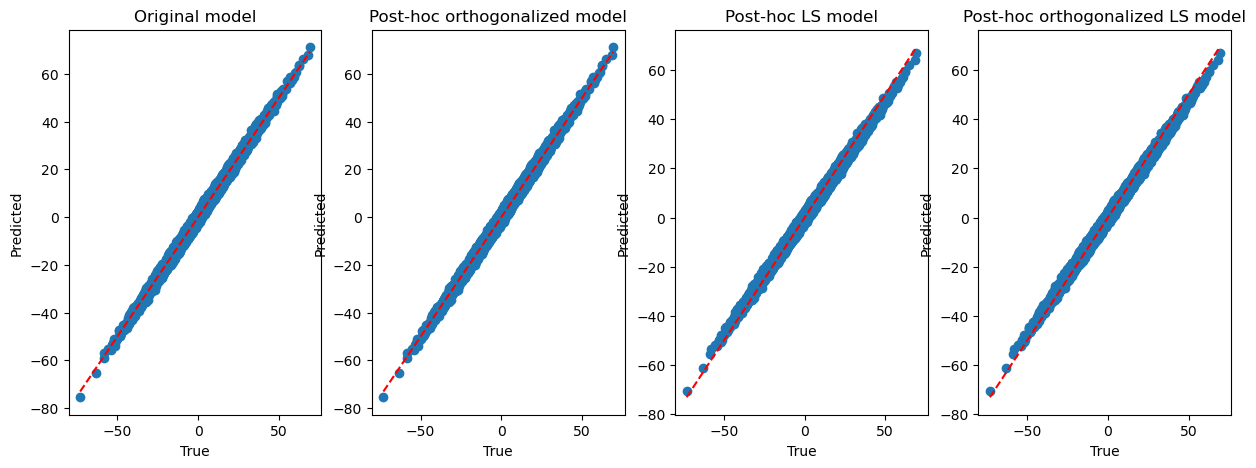

In [10]:
# Residualplot of all models with same plot limits.
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))
plt.subplot(1, 4, 1)
plt.scatter(y, net(U, X).detach().numpy())
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.title("Original model")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.subplot(1, 4, 2)
plt.scatter(y, pho(U, X).detach().numpy())
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.title("Post-hoc orthogonalized model")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.subplot(1, 4, 3)
plt.scatter(y, phls(U, X).detach().numpy())
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.title("Post-hoc LS model")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.subplot(1, 4, 4)
plt.scatter(y, phols(U, X).detach().numpy())
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.title("Post-hoc orthogonalized LS model")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()